In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras

from keras.layers import Input, Flatten, Dense
from keras.optimizers import Adam
from keras.datasets import fashion_mnist
from keras.utils import to_categorical
from deel import torchlip
import numpy as np
import keras.ops as K
import matplotlib.pyplot as plt
import torch
import math
import pickle
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np

import sys
sys.path.append('/home/aws_install/robustess_project/lip_notebooks/')
from data_processing import load_data, select_data_for_radius_evaluation
from radius_evaluation_tools_torch import compute_certificate
sys.path.append('/home/aws_install/robustess_project/lip_notebooks/AbstractInterpretation')
from abstract_interpretation_tools import load_MNIST
sys.path.append("/home/aws_install/robustess_project/lip_notebooks/LipschitzOptimization")
from lipschitz_optimization_tools_torch import echantillonner_boule_l2_simple


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
print("loading model")
pytorch_model = load_MNIST().to(device)

print("loading dataset")
# Define the directory and file paths
output_dir = "./../benchmark_dataset_MNIST"
images_path = os.path.join(output_dir, "images.pkl")
targets_path = os.path.join(output_dir, "targets.pkl")

# --- Load the Tensors ---
print(f"Loading data from {output_dir}...")

# Load the images tensor
with open(images_path, 'rb') as f:
    images = pickle.load(f)

# Load the targets tensor
with open(targets_path, 'rb') as f:
    labels = pickle.load(f)
    
images = images.to(device)
labels = labels.to(device)


loading model
--create torch model : --


/home/aws_install/miniconda3/envs/k3torchenv/lib/python3.10/site-packages/deel/torchlip/modules/module.py:159: UserWarning: Sequential model contains a layer which is not a Lipschitz layer: MaxMin()
  warnings.warn(
/home/aws_install/miniconda3/envs/k3torchenv/lib/python3.10/site-packages/deel/torchlip/modules/module.py:159: UserWarning: Sequential model contains a layer which is not a Lipschitz layer: FlattenChannelLast()
  warnings.warn(


loading dataset
Loading data from ./../benchmark_dataset_MNIST...


In [4]:
def choose_point(idx):    
    idx = 5
    x_test = images[idx:idx+1]
    y_test = labels[idx:idx+1]
    certificate = compute_certificate(images, pytorch_model)[idx]
    return x_test, y_test, certificate

In [5]:
def calculate_certified_radius(logits: torch.Tensor) -> torch.Tensor:
    """
    Calculates the certified radius for a batch of predictions, assuming
    the top prediction is the ground truth.

    This function implements the formula: (logit_top1 - logit_top2) / sqrt(2).
    It is a simplified version that is only correct when the highest logit
    corresponds to the ground truth class.

    Args:
        logits (torch.Tensor): The raw output from a model for a batch of inputs.
                               Expected shape: [batch_size, num_classes].

    Returns:
        torch.Tensor: A tensor of shape [batch_size] containing the certified
                      radius for each item in the batch.
    """
    # --- Step 1: Get the top two logits ---
    # This is much simpler because we assume the top logit is the ground truth.
    top2_values, _ = torch.topk(logits, 2, dim=1)

    logit_gt = top2_values[:, 0]
    logit_top2 = top2_values[:, 1]

    # --- Step 2: Perform the final calculation ---
    # (logit_gt - logit_top2) / sqrt(2)
    numerator = logit_gt - logit_top2
    denominator = math.sqrt(2.0)
    
    certified_radius = numerator / denominator

    return certified_radius

In [6]:
def echantillonner_boule_l2_point_unique(x_point, epsilon, n_samples, uniform=False):
    """
    Génère n_samples points dans la boule L2 définie par un seul point et un seul rayon.

    Args:
        x_point (np.ndarray): Le point central de la boule. Shape: (d,).
        epsilon (float): Le rayon de la boule.
        n_samples (int): Le nombre d'échantillons à générer.
        uniform (bool): Si True, échantillonne uniformément dans le volume.

    Returns:
        np.ndarray: Un tableau de n_samples points échantillonnés. Shape: (n_samples, d).
    """
    x_point_vector = x_point.reshape(-1)
    # x_point = x_point.squeeze()
    # 1. Préparer les données pour la fonction de traitement par lot.
    # On répète le point central n_samples fois.
    # np.newaxis ajoute une dimension pour le lot : (d,) -> (1, d)
    # np.repeat crée le lot final : (1, d) -> (n_samples, d)
    x_batch = np.repeat(x_point_vector[np.newaxis, :], n_samples, axis=0)
    # print(x_batch.shape)
    # On crée un tableau de n_samples rayons, tous identiques.
    epsilons_batch = np.full(n_samples, epsilon)

    # 2. Appeler la fonction de lot efficace pour faire le calcul.
    return echantillonner_boule_l2_batch(x_batch, epsilons_batch, uniform=uniform)

# --- La fonction de bas niveau pour le traitement par lot (inchangée) ---
def echantillonner_boule_l2_batch(x_batch, epsilons, uniform=False):
    N, d = x_batch.shape
    u = np.random.randn(N, d)
    norm_u = np.linalg.norm(u, axis=1, keepdims=True)
    norm_u[norm_u == 0] = 1e-9
    s = np.random.rand(N)
    if uniform:
        r = epsilons * s**(1/d)
    else:
        r = epsilons * s

    # print(r)
    r = r.reshape(-1, 1)
    y = x_batch + r * (u / norm_u)
    return y

In [11]:
def compute_norms(x_test, certificate, N_Samples=1000, C = 1, H=28, W=28, verbose=False):
    # Conversion en NumPy
    x_np = x_test.cpu().detach().numpy()
    certificates_np = certificate.cpu().detach().numpy()

    # Échantillonnage (cette partie est correcte)
    sample_np = echantillonner_boule_l2_point_unique(x_np, certificates_np, N_Samples)
    # Préparation pour PyTorch
    # Les échantillons sont des vecteurs de forme (1000, 784)
    y_vectors = torch.tensor(sample_np, dtype=torch.float32, requires_grad=True).cuda()

    # On les remet en forme d'images si le modèle est un CNN
    y_images = y_vectors.reshape(N_Samples, C, H, W)

    # On garde la trace du gradient sur le tenseur qui entre dans le modèle
    y_images.retain_grad()

    # Passe avant et arrière
    logits = pytorch_model(y_images)
    loss_vector = calculate_certified_radius(logits) # e.g., shape (1000,)

    # ================================================================= #
    # FIX 1 : Agréger la perte en un scalaire avant d'appeler .backward()
    # ================================================================= #
    loss_scalar = loss_vector.sum()
    loss_scalar.backward()

    # Obtenir le gradient
    # y_images.grad aura la forme (1000, 1, 28, 28)
    gradient = y_images.grad

    # ================================================================= #
    # FIX 2 : Calculer correctement la norme pour des gradients en forme d'image
    # ================================================================= #
    # Mettre à plat les gradients de chaque image en vecteurs
    gradient_flat = gradient.reshape(N_Samples, -1) # Shape -> (1000, 784)
    # Calculer la norme sur la dimension des vecteurs
    norms = gradient_flat.norm(p=2, dim=1) # Shape -> (1000,)

    if verbose:
        # Affichage des résultats
        print(f"Shape du gradient (en images): {gradient.shape}")
        print(f"Shape du tenseur des normes: {norms.shape}")
        print(f"Normes calculées pour les 5 premiers points:\n{norms[:5]}")
    return norms.max(), norms

In [8]:
def plot_global(norms):
    # --- We assume the 'norms' tensor already exists and is on the GPU ---
    # Example of dummy data if you're running this block separately
    # norms = torch.randn(1000).abs() * 0.5 

    # ================================================================= #
    # 1. Prepare the data for plotting
    # ================================================================= #
    # Matplotlib and Seaborn work with NumPy arrays on the CPU.
    # Therefore, we need to move the tensor from the GPU to the CPU and convert it.
    norms_np = norms.cpu().detach().numpy()


    # ================================================================= #
    # 2. Create the plot with Seaborn (recommended)
    # ================================================================= #

    # Apply an aesthetic style to the plot
    sns.set_theme(style="whitegrid")

    # Create a figure with a suitable size
    plt.figure(figsize=(12, 7))

    # Create the histogram and density curve (KDE)
    sns.histplot(norms_np, kde=True, bins=50, label="Distribution of Norms")

    # Calculate and display the mean and standard deviation for context
    mean_norm = norms_np.mean()
    std_norm = norms_np.std()

    # Add a vertical line to mark the position of the mean
    plt.axvline(mean_norm, color='r', linestyle='--', linewidth=2, label=f"Mean: {mean_norm:.4f}")

    # Add titles and labels for clarity
    plt.title("Distribution of the Maximal Gradient Norm for 200 Samples", fontsize=16)
    plt.xlabel("L2 Norm of the Gradient", fontsize=12)
    plt.ylabel("Number of Samples (Frequency)", fontsize=12)
    plt.legend() # Display the legend

    # Display the final plot
    plt.show()

    # Print the statistics in the console
    print(f"Statistics on the gradient norms:")
    print(f"Mean       : {mean_norm:.4f}")
    print(f"Std. Dev.  : {std_norm:.4f}")
    print(f"Median     : {np.median(norms_np):.4f}")
    print(f"Minimum    : {norms_np.min():.4f}")
    print(f"Maximum    : {norms_np.max():.4f}")


def plot_single_points(norms):
    # --- We assume the 'norms' tensor already exists and is on the GPU ---
    # Example of dummy data if you're running this block separately
    # norms = torch.randn(1000).abs() * 0.5 

    # ================================================================= #
    # 1. Prepare the data for plotting
    # ================================================================= #
    # Matplotlib and Seaborn work with NumPy arrays on the CPU.
    # Therefore, we need to move the tensor from the GPU to the CPU and convert it.
    norms_np = norms.cpu().detach().numpy()


    # ================================================================= #
    # 2. Create the plot with Seaborn (recommended)
    # ================================================================= #

    # Apply an aesthetic style to the plot
    sns.set_theme(style="whitegrid")

    # Create a figure with a suitable size
    plt.figure(figsize=(12, 7))

    # Create the histogram and density curve (KDE)
    sns.histplot(norms_np, kde=True, bins=50, label="Distribution of Norms")

    # Calculate and display the mean and standard deviation for context
    mean_norm = norms_np.mean()
    std_norm = norms_np.std()

    # Add a vertical line to mark the position of the mean
    plt.axvline(mean_norm, color='r', linestyle='--', linewidth=2, label=f"Mean: {mean_norm:.4f}")

    # Add titles and labels for clarity
    plt.title("Distribution of the Gradient Norm for 1000 Samples", fontsize=16)
    plt.xlabel("L2 Norm of the Gradient", fontsize=12)
    plt.ylabel("Number of Samples (Frequency)", fontsize=12)
    plt.legend() # Display the legend

    # Display the final plot
    plt.show()

    # Print the statistics in the console
    print(f"Statistics on the gradient norms:")
    print(f"Mean       : {mean_norm:.4f}")
    print(f"Std. Dev.  : {std_norm:.4f}")
    print(f"Median     : {np.median(norms_np):.4f}")
    print(f"Minimum    : {norms_np.min():.4f}")
    print(f"Maximum    : {norms_np.max():.4f}")

In [13]:
max_norms = []
for idx in range(len(images)):
    x_test, _, certificate = choose_point(idx)
    max_norms.append(compute_norms(x_test, certificate)[0])
max_norms = torch.tensor(max_norms, dtype=torch.float32)

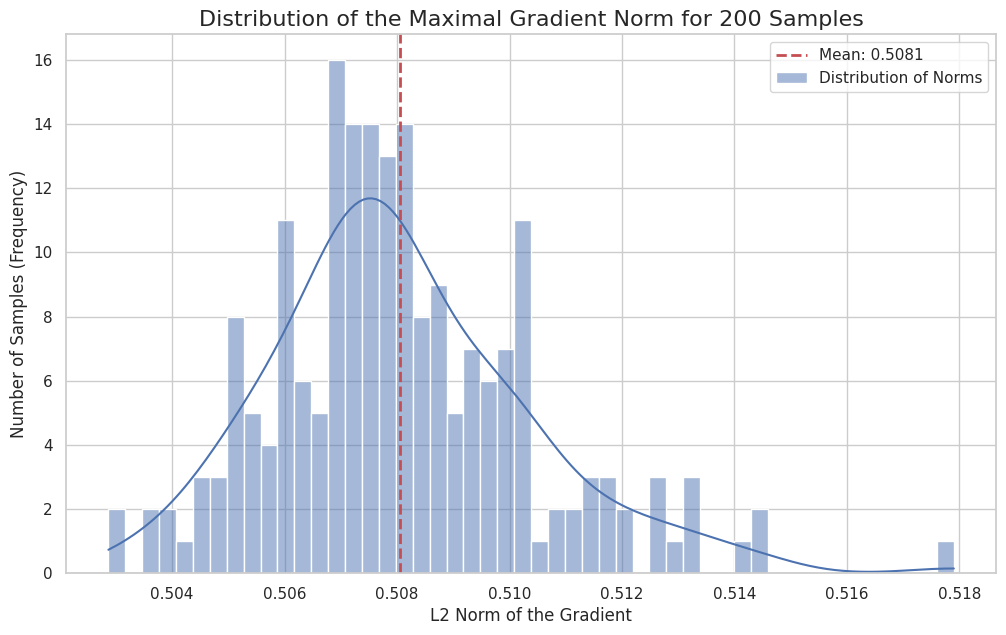

Statistics on the gradient norms:
Mean       : 0.5081
Std. Dev.  : 0.0023
Median     : 0.5077
Minimum    : 0.5029
Maximum    : 0.5179


In [14]:
plot_global(max_norms)

/tmp/ipykernel_2880/2190201244.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  norms = torch.tensor(norms, dtype=torch.float32)


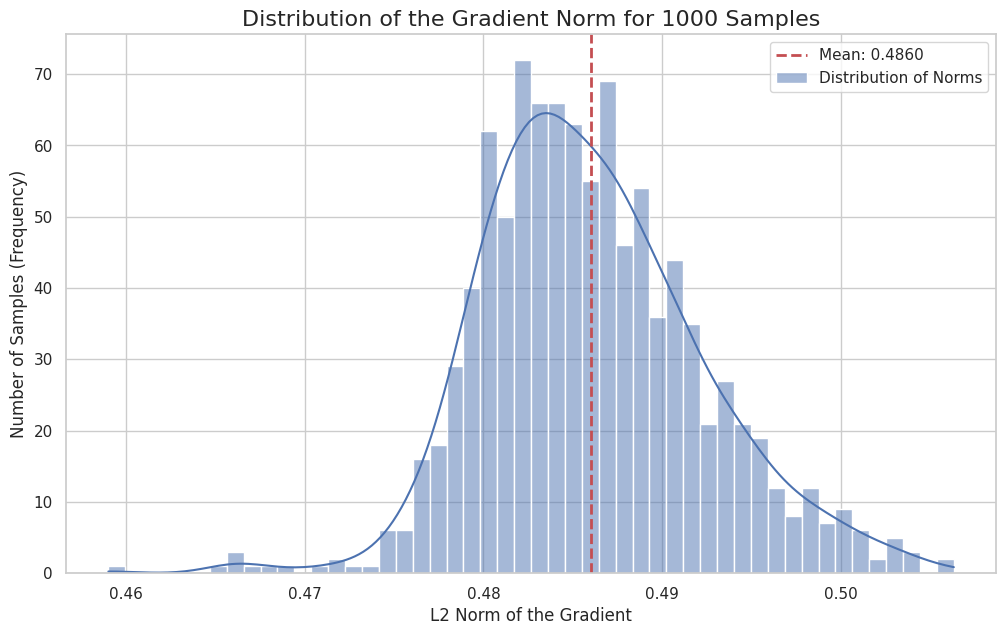

Statistics on the gradient norms:
Mean       : 0.4860
Std. Dev.  : 0.0062
Median     : 0.4853
Minimum    : 0.4590
Maximum    : 0.5063


In [17]:
x_test, _, certificate = choose_point(5)
norms=compute_norms(x_test, certificate)[1]
norms = torch.tensor(norms, dtype=torch.float32)
plot_single_points(norms)